## Basic Polynomial Regression Implementation

In [1]:
import math
import random

class PolynomialRegression:
    def __init__(self, degree=2):
        """
        degree: The degree of the polynomial (e.g., 2 for quadratic, 3 for cubic)
        """
        self.degree = degree
        self.weights = []      # Coefficients for x¹, x², ..., x^degree
        self.intercept = 0.0   # Bias term
    
    def _create_polynomial_features(self, X):
        """
        Transform input X into polynomial features: [x, x², x³, ..., x^degree]
        """
        if isinstance(X, (int, float)):
            return [X ** d for d in range(1, self.degree + 1)]
        return [[x ** d for d in range(1, self.degree + 1)] for x in X]
    
    def fit_normal_equation(self, X, y):
        """
        Fit using Normal Equation with polynomial features
        """
        # Create polynomial features
        X_poly = self._create_polynomial_features(X)
        n_samples = len(X)
        n_features = self.degree
        
        # Add column of ones for intercept
        X_design = [[1] + row for row in X_poly]
        
        # Solve using normal equation
        # X^T * X
        XT = [[X_design[j][i] for j in range(n_samples)] for i in range(n_features + 1)]
        XTX = [[sum(XT[i][k] * X_design[k][j] for k in range(n_samples)) 
                for j in range(n_features + 1)] for i in range(n_features + 1)]
        
        # Inverse of XTX
        XTX_inv = self._matrix_inverse(XTX)
        
        # X^T * y
        XTy = [sum(XT[i][j] * y[j] for j in range(n_samples)) for i in range(n_features + 1)]
        
        # Solve
        weights = [sum(XTX_inv[i][j] * XTy[j] for j in range(n_features + 1)) 
                   for i in range(n_features + 1)]
        
        self.intercept = weights[0]
        self.weights = weights[1:]
        return self
    
    def _matrix_inverse(self, matrix):
        """Gauss-Jordan elimination for matrix inversion"""
        n = len(matrix)
        aug = [row[:] + [1 if i == j else 0 for j in range(n)] for i, row in enumerate(matrix)]
        
        for i in range(n):
            pivot = aug[i][i]
            if pivot == 0:
                for k in range(i + 1, n):
                    if aug[k][i] != 0:
                        aug[i], aug[k] = aug[k], aug[i]
                        pivot = aug[i][i]
                        break
            
            for j in range(2 * n):
                aug[i][j] /= pivot
            
            for k in range(n):
                if k != i:
                    factor = aug[k][i]
                    for j in range(2 * n):
                        aug[k][j] -= factor * aug[i][j]
        
        return [row[n:] for row in aug]
    
    def fit_gradient_descent(self, X, y, learning_rate=0.01, epochs=1000):
        """
        Fit using Gradient Descent
        """
        X_poly = self._create_polynomial_features(X)
        n_samples = len(X)
        n_features = self.degree
        
        # Initialize weights
        self.weights = [random.uniform(-0.1, 0.1) for _ in range(n_features)]
        self.intercept = 0.0
        self.cost_history = []
        
        for epoch in range(epochs):
            predictions = self._predict_poly(X_poly)
            
            # Gradients
            gradient_weights = []
            for j in range(n_features):
                grad = (2 / n_samples) * sum((predictions[i] - y[i]) * X_poly[i][j] 
                                              for i in range(n_samples))
                gradient_weights.append(grad)
            
            gradient_intercept = (2 / n_samples) * sum(predictions[i] - y[i] 
                                                        for i in range(n_samples))
            
            # Update
            for j in range(n_features):
                self.weights[j] -= learning_rate * gradient_weights[j]
            self.intercept -= learning_rate * gradient_intercept
            
            # Track cost
            cost = self.compute_cost(X, y)
            self.cost_history.append(cost)
            
            if epoch % 200 == 0:
                print(f"Epoch {epoch:4d} | Cost: {cost:.6f}")
        
        return self
    
    def _predict_poly(self, X_poly):
        """Predict using polynomial features"""
        return [sum(w * x for w, x in zip(self.weights, row)) + self.intercept 
                for row in X_poly]
    
    def predict(self, X):
        """Make predictions for new data"""
        X_poly = self._create_polynomial_features(X)
        if isinstance(X_poly[0], list):
            return [sum(w * x for w, x in zip(self.weights, row)) + self.intercept 
                    for row in X_poly]
        else:
            return sum(w * x for w, x in zip(self.weights, X_poly)) + self.intercept
    
    def compute_cost(self, X, y):
        """Mean Squared Error"""
        predictions = self.predict(X)
        n = len(y)
        return sum((predictions[i] - y[i]) ** 2 for i in range(n)) / (2 * n)
    
    def r_squared(self, X, y):
        """R-squared score"""
        predictions = self.predict(X)
        y_mean = sum(y) / len(y)
        ss_res = sum((y[i] - predictions[i]) ** 2 for i in range(len(y)))
        ss_tot = sum((y[i] - y_mean) ** 2 for i in range(len(y)))
        return 1 - (ss_res / ss_tot)
    
    def __str__(self):
        """Display the polynomial equation"""
        terms = []
        for i, w in enumerate(self.weights):
            if abs(w) > 1e-6:
                sign = "+" if w >= 0 else ""
                terms.append(f"{sign}{w:.4f}x^{i+1}")
        if abs(self.intercept) > 1e-6:
            sign = "+" if self.intercept >= 0 else ""
            terms.append(f"{sign}{self.intercept:.4f}")
        return "y = " + " ".join(terms)

# Example usage
if __name__ == "__main__":
    # Generate nonlinear data: y = 0.5x² - 2x + 3 + noise
    random.seed(42)
    X = [x / 10.0 for x in range(0, 100)]  # 0 to 9.9
    y = [0.5 * x**2 - 2 * x + 3 + random.gauss(0, 0.3) for x in X]
    
    print("=== Polynomial Regression from Scratch ===")
    print(f"True relationship: y = 0.5x² - 2x + 3")
    
    # Test different degrees
    for degree in [1, 2, 3, 5]:
        model = PolynomialRegression(degree=degree)
        model.fit_normal_equation(X, y)
        r2 = model.r_squared(X, y)
        print(f"\nDegree {degree}:")
        print(f"  R² = {r2:.4f}")
        print(f"  Equation: {model}")

=== Polynomial Regression from Scratch ===
True relationship: y = 0.5x² - 2x + 3

Degree 1:
  R² = 0.8385
  Equation: y = +2.9609x^1 -5.1212

Degree 2:
  R² = 0.9992
  Equation: y = -2.0096x^1 +0.5021x^2 +2.9972

Degree 3:
  R² = 0.9992
  Equation: y = -1.9803x^1 +0.4946x^2 +0.0005x^3 +2.9736

Degree 5:
  R² = 0.9992
  Equation: y = -1.7685x^1 +0.3058x^2 +0.0589x^3 -0.0073x^4 +0.0003x^5 +2.9314


## NumPy Implementation

=== NumPy Polynomial Regression ===

Equation: y = + 1.3313x^1 - 0.4792x^2 + 0.2592x^3 + 1.2215
R² Score: 0.9966


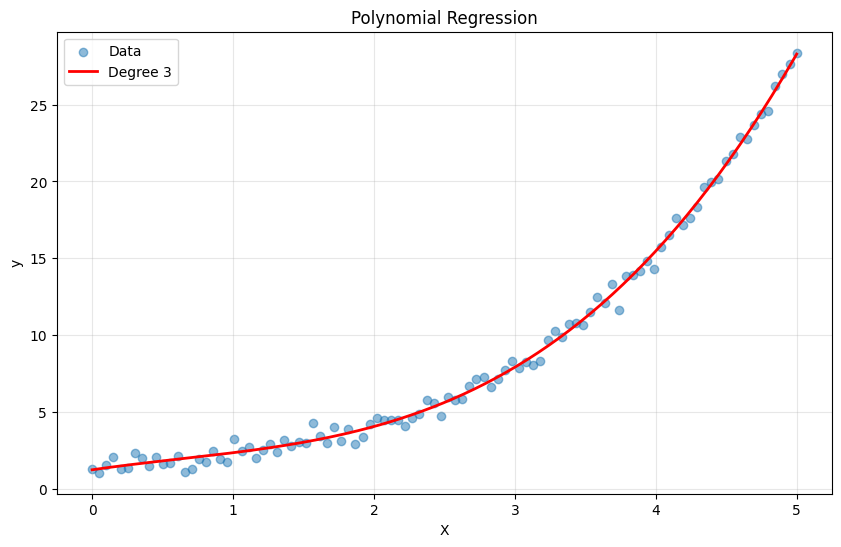

In [2]:
import numpy as np

class PolynomialRegressionNumpy:
    def __init__(self, degree=2):
        self.degree = degree
        self.weights = None
        self.intercept = None
    
    def _create_poly_features(self, X):
        """Create polynomial features using vectorized operations"""
        X = np.array(X).reshape(-1, 1)
        # Create [x, x², x³, ..., x^degree]
        return np.hstack([X ** i for i in range(1, self.degree + 1)])
    
    def fit_normal_equation(self, X, y):
        """Fit using Normal Equation"""
        X = np.array(X)
        y = np.array(y)
        
        # Create polynomial features
        X_poly = self._create_poly_features(X)
        
        # Add bias term
        X_b = np.c_[np.ones((len(X), 1)), X_poly]
        
        # Normal equation
        weights = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
        
        self.intercept = weights[0]
        self.weights = weights[1:]
        return self
    
    def fit_gradient_descent(self, X, y, learning_rate=0.01, epochs=1000):
        """Fit using Gradient Descent"""
        X = np.array(X)
        y = np.array(y)
        n_samples = len(X)
        
        # Create polynomial features
        X_poly = self._create_poly_features(X)
        
        # Initialize weights
        self.weights = np.random.randn(self.degree) * 0.01
        self.intercept = 0.0
        self.cost_history = []
        
        for epoch in range(epochs):
            predictions = X_poly @ self.weights + self.intercept
            
            # Gradients (vectorized)
            dw = (2 / n_samples) * X_poly.T @ (predictions - y)
            db = (2 / n_samples) * np.sum(predictions - y)
            
            # Update
            self.weights -= learning_rate * dw
            self.intercept -= learning_rate * db
            
            cost = np.mean((predictions - y) ** 2) / 2
            self.cost_history.append(cost)
            
            if epoch % 200 == 0:
                print(f"Epoch {epoch:4d} | Cost: {cost:.6f}")
        
        return self
    
    def predict(self, X):
        """Make predictions"""
        X = np.array(X)
        X_poly = self._create_poly_features(X)
        return X_poly @ self.weights + self.intercept
    
    def score(self, X, y):
        """R-squared score"""
        X, y = np.array(X), np.array(y)
        y_pred = self.predict(X)
        y_mean = np.mean(y)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y_mean) ** 2)
        return 1 - (ss_res / ss_tot)
    
    def get_equation(self):
        """Return polynomial equation as string"""
        terms = []
        for i, w in enumerate(self.weights):
            if abs(w) > 1e-6:
                sign = "+" if w >= 0 else "-"
                terms.append(f"{sign} {abs(w):.4f}x^{i+1}")
        if abs(self.intercept) > 1e-6:
            sign = "+" if self.intercept >= 0 else "-"
            terms.append(f"{sign} {abs(self.intercept):.4f}")
        return "y = " + " ".join(terms)

# Example
if __name__ == "__main__":
    import matplotlib.pyplot as plt
    
    np.random.seed(42)
    X = np.linspace(0, 5, 100)
    # y = 0.3x³ - 0.8x² + 2x + 1 + noise
    y = 0.3 * X**3 - 0.8 * X**2 + 2 * X + 1 + np.random.normal(0, 0.5, 100)
    
    print("=== NumPy Polynomial Regression ===")
    
    # Fit polynomial of degree 3
    model = PolynomialRegressionNumpy(degree=3)
    model.fit_normal_equation(X, y)
    
    print(f"\nEquation: {model.get_equation()}")
    print(f"R² Score: {model.score(X, y):.4f}")
    
    # Visualize
    plt.figure(figsize=(10, 6))
    plt.scatter(X, y, alpha=0.5, label='Data')
    
    X_plot = np.linspace(0, 5, 200)
    y_plot = model.predict(X_plot)
    plt.plot(X_plot, y_plot, 'r-', linewidth=2, label=f'Degree {model.degree}')
    
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title('Polynomial Regression')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## Scikit-Learn Implementation 

=== Polynomial Regression with Scikit-Learn ===
Training samples: 160, Test samples: 40


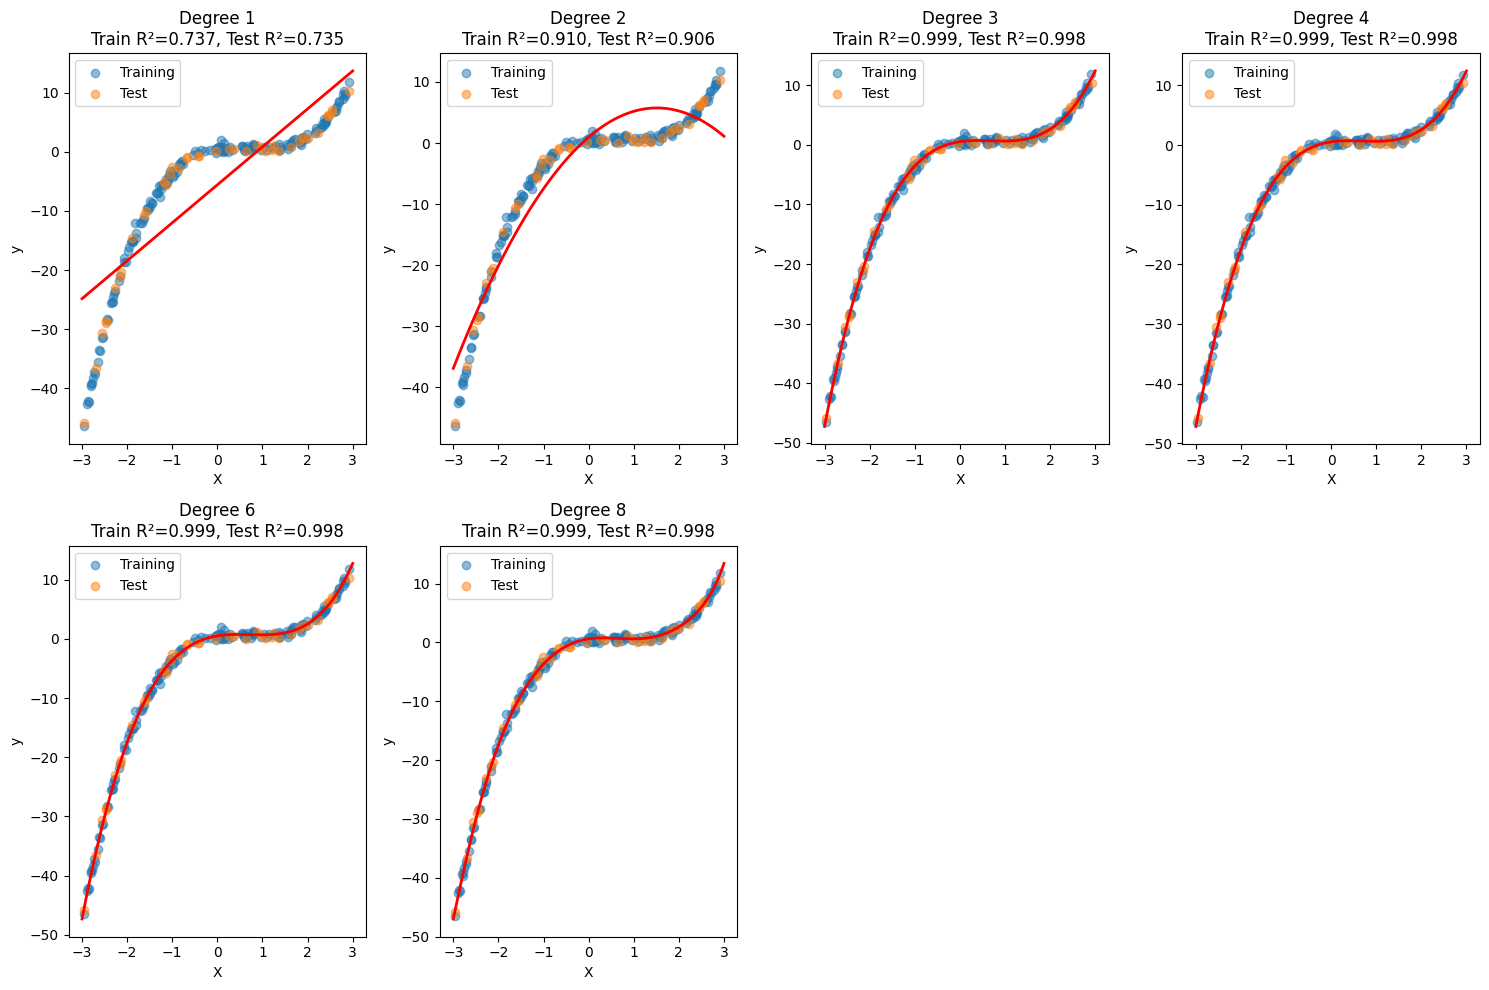


=== Model Comparison ===
Degree | Train R² | Test R² | RMSE
---------------------------------------------
     1 | 0.7367  | 0.7346  | 6.6999
     2 | 0.9104  | 0.9061  | 3.9846
     3 | 0.9987  | 0.9984  | 0.5253
     4 | 0.9987  | 0.9983  | 0.5283
     6 | 0.9988  | 0.9983  | 0.5408
     8 | 0.9988  | 0.9981  | 0.5693

Best degree: 3 (R² = 0.9984)


In [3]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Generate nonlinear data
np.random.seed(42)
n_samples = 200
X = np.random.uniform(-3, 3, (n_samples, 1))
# True function: y = x³ - 2x² + x + 0.5 + noise
y = X.ravel()**3 - 2*X.ravel()**2 + X.ravel() + 0.5 + np.random.normal(0, 0.5, n_samples)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("=== Polynomial Regression with Scikit-Learn ===")
print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

# Try different polynomial degrees
degrees = [1, 2, 3, 4, 6, 8]
results = []

plt.figure(figsize=(15, 10))

for idx, degree in enumerate(degrees, 1):
    # Create pipeline
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('linear', LinearRegression())
    ])
    
    # Train
    model.fit(X_train, y_train)
    
    # Evaluate
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    
    results.append({
        'degree': degree,
        'train_r2': r2_train,
        'test_r2': r2_test,
        'rmse': np.sqrt(mean_squared_error(y_test, y_pred_test))
    })
    
    # Plot
    plt.subplot(2, 4, idx)
    plt.scatter(X_train, y_train, alpha=0.5, label='Training')
    plt.scatter(X_test, y_test, alpha=0.5, label='Test')
    
    X_plot = np.linspace(-3, 3, 100).reshape(-1, 1)
    y_plot = model.predict(X_plot)
    plt.plot(X_plot, y_plot, 'r-', linewidth=2)
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title(f'Degree {degree}\nTrain R²={r2_train:.3f}, Test R²={r2_test:.3f}')
    plt.legend()

plt.tight_layout()
plt.show()

# Print results
print("\n=== Model Comparison ===")
print("Degree | Train R² | Test R² | RMSE")
print("-" * 45)
for r in results:
    print(f"{r['degree']:6d} | {r['train_r2']:.4f}  | {r['test_r2']:.4f}  | {r['rmse']:.4f}")

# Find best degree
best = max(results, key=lambda x: x['test_r2'])
print(f"\nBest degree: {best['degree']} (R² = {best['test_r2']:.4f})")

## With Regularization

=== Polynomial Regression with Regularization ===


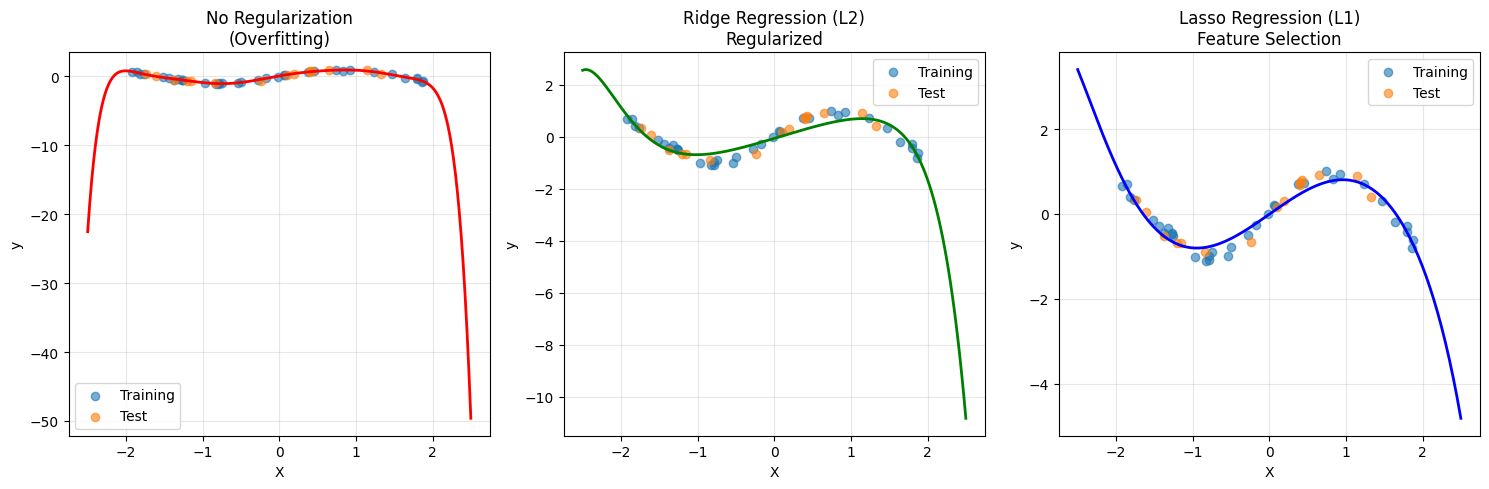


=== Coefficient Comparison ===
Plain LR: 10 features
Ridge: 10 features with non-zero coeff
Lasso: 4 features with non-zero coeff

=== R² Scores ===
Plain LR (Test): 0.9705
Ridge (Test): 0.7950
Lasso (Test): 0.9168


In [5]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

# Generate high-degree polynomial data (overfitting example)
np.random.seed(42)
n_samples = 50
X = np.random.uniform(-2, 2, (n_samples, 1))
y = np.sin(X.ravel() * 2) + np.random.normal(0, 0.1, n_samples)  # Sinusoidal

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("=== Polynomial Regression with Regularization ===")

def create_model(model_type='ridge', degree=10, alpha=1.0):
    """Create pipeline with polynomial features and regularization"""
    if model_type == 'ridge':
        return Pipeline([
            ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
            ('scaler', StandardScaler()),
            ('model', Ridge(alpha=alpha))
        ])
    else:  # lasso
        return Pipeline([
            ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
            ('scaler', StandardScaler()),
            ('model', Lasso(alpha=alpha, max_iter=10000))
        ])

# Compare regularized vs unregularized
plt.figure(figsize=(15, 5))

# 1. Unregularized (LinearRegression)
plt.subplot(1, 3, 1)
model_plain = Pipeline([
    ('poly', PolynomialFeatures(degree=10, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
model_plain.fit(X_train, y_train)

X_plot = np.linspace(-2.5, 2.5, 200).reshape(-1, 1)
y_plot = model_plain.predict(X_plot)

plt.scatter(X_train, y_train, alpha=0.6, label='Training')
plt.scatter(X_test, y_test, alpha=0.6, label='Test')
plt.plot(X_plot, y_plot, 'r-', linewidth=2)
plt.title('No Regularization\n(Overfitting)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Ridge Regression (L2)
plt.subplot(1, 3, 2)
model_ridge = create_model('ridge', degree=10, alpha=1.0)
model_ridge.fit(X_train, y_train)
y_plot = model_ridge.predict(X_plot)

plt.scatter(X_train, y_train, alpha=0.6, label='Training')
plt.scatter(X_test, y_test, alpha=0.6, label='Test')
plt.plot(X_plot, y_plot, 'g-', linewidth=2)
plt.title('Ridge Regression (L2)\nRegularized')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Lasso Regression (L1)
plt.subplot(1, 3, 3)
model_lasso = create_model('lasso', degree=10, alpha=0.01)
model_lasso.fit(X_train, y_train)
y_plot = model_lasso.predict(X_plot)

plt.scatter(X_train, y_train, alpha=0.6, label='Training')
plt.scatter(X_test, y_test, alpha=0.6, label='Test')
plt.plot(X_plot, y_plot, 'b-', linewidth=2)
plt.title('Lasso Regression (L1)\nFeature Selection')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print coefficients
print("\n=== Coefficient Comparison ===")
print(f"Plain LR: {len(model_plain.named_steps['model'].coef_)} features")
print(f"Ridge: {np.sum(np.abs(model_ridge.named_steps['model'].coef_) > 1e-5)} features with non-zero coeff")
print(f"Lasso: {np.sum(np.abs(model_lasso.named_steps['model'].coef_) > 1e-5)} features with non-zero coeff")

# Print R² scores
print("\n=== R² Scores ===")
print(f"Plain LR (Test): {model_plain.score(X_test, y_test):.4f}")
print(f"Ridge (Test): {model_ridge.score(X_test, y_test):.4f}")
print(f"Lasso (Test): {model_lasso.score(X_test, y_test):.4f}")